# Comparing Results from 4 Regression Models: Timepoint T4 Models
### ElasticNet, Support Vector Regression, Partial Least Squares Regression, HistGradientBoosting Regressor

In [1]:
# Importing and loading results
import sys, os
sys.path.insert(0, '../src')
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skrub import TableReport
import joblib, os
import preprocess
import explore
import model
os.environ['PYTHONWARNINGS'] = 'ignore'
MODEL_DIR = os.path.abspath('../models/pain-reduction')

# Performance Metrics against Selected Features
### From Feature Frequency Lists

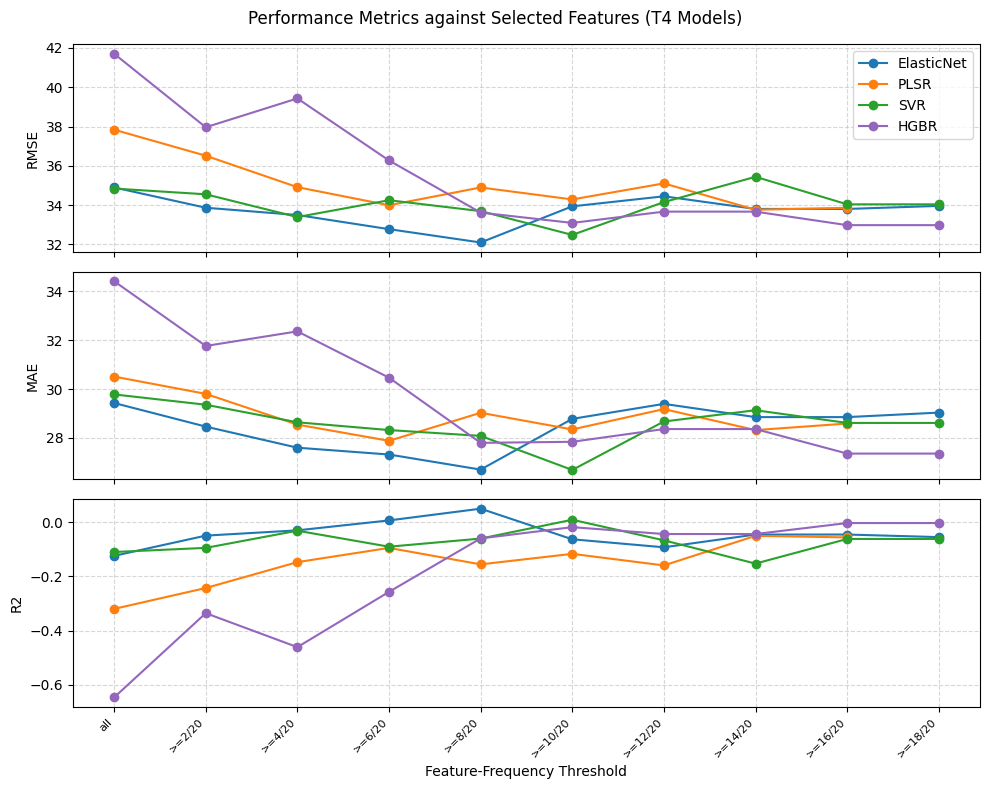

In [2]:
en_sweep = joblib.load(os.path.join(MODEL_DIR, 'en_sweep_df4.pkl'))
svr_sweep = joblib.load(os.path.join(MODEL_DIR, 'svr_sweep_df4.pkl'))
pls_sweep = joblib.load(os.path.join(MODEL_DIR, 'pls_sweep_df4.pkl'))
hgbr_sweep = joblib.load(os.path.join(MODEL_DIR, 'hgbr_sweep_df4.pkl'))
importlib.reload(model)
model.plot_sweep({'ElasticNet': en_sweep,
        'PLSR':   pls_sweep,
        'SVR':        svr_sweep,
        'HGBR':       hgbr_sweep}, title='Performance Metrics against Selected Features (T4 Models)')

## Summary: Mean Performance Metrics for All T4  Final Models

In [4]:
import pandas as pd
# Summary from Modeling-Notebooks
summary = pd.DataFrame({
    'Model':               ['ElasticNet',         'SVR',             'PLSR',          'HGBR'],
    'Cut-Off Feature sel.':['>=8/20',           '>=10/20',        '>=14/20',      '>=10/20'],
    'Mean RMSE':           ['32.102 ± 3.781', '32.487 ± 4.001', '33.767 ± 3.629', '32.926 ± 3.475'],
    'Mean MAE':            ['26.701 ± 2.646', '26.687 ± 2.426', '28.319 ± 2.947', '27.702 ± 3.209'],
    'Mean R2':             ['0.050 ± 0.155', '0.009 ± 0.262', '-0.050 ± 0.157', '-0.007 ± 0.194'],
})

summary.set_index('Model', inplace=True)
display(summary)

,Cut-Off Feature sel.,Mean RMSE,Mean MAE,Mean R2
Model,,,,
ElasticNet,>=8/20,32.102 ± 3.781,26.701 ± 2.646,0.050 ± 0.155
SVR,>=10/20,32.487 ± 4.001,26.687 ± 2.426,0.009 ± 0.262
PLSR,>=14/20,33.767 ± 3.629,28.319 ± 2.947,-0.050 ± 0.157
HGBR,>=10/20,32.926 ± 3.475,27.702 ± 3.209,-0.007 ± 0.194


## Significance testing
# Pairwise t-tests between Model Performance Metrics
Comparing performance metrics across 4 models, computing p-values and plotting heatmaps


  Pairwise Paired t-test (α=0.05)

  ElasticNet vs SVR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.5413      no
  MAE          0.9805      no
  R2           0.3278      no

  ElasticNet vs PLSR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0023    *YES
  MAE          0.0017    *YES
  R2           0.0044    *YES

  ElasticNet vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.2289      no
  MAE          0.1594      no
  R2           0.1916      no

  SVR vs PLSR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0505      no
  MAE          0.0100    *YES
  R2           0.1770      no

  SVR vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.4678      no
  MAE          0.0620      no
  R2           0.6785      no

  PLSR vs HGBR
  Metric      p-value     Sig
  ----------------------------
  RMSE         0.0968      no
  MAE   

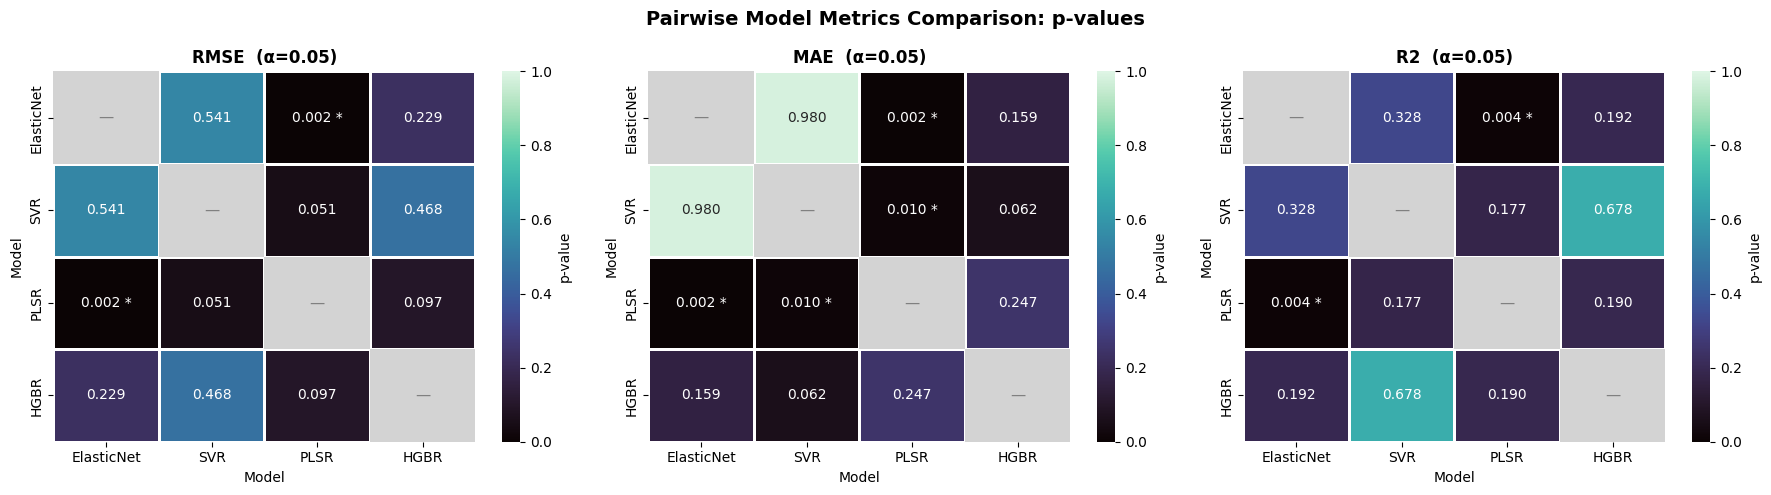

In [3]:
importlib.reload(model)
results_dict = {
    'ElasticNet': joblib.load(os.path.join(MODEL_DIR, 'en_results_df4.pkl')),
    'SVR':        joblib.load(os.path.join(MODEL_DIR, 'svr_results4.pkl')),
    'PLSR':        joblib.load(os.path.join(MODEL_DIR, 'pls_results4.pkl')),
    'HGBR':       joblib.load(os.path.join(MODEL_DIR, 'hgbr_results4.pkl')),
}

p_vals = model.pairwise_metric_comparison(results_dict, alpha=0.05)